### Initialization libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv("household_dataset.csv")
df

,Household_ID,Age_of_Household_Head,Household_Income,Education_Level,Family_Size,Owns_House,Urban_Rural
0,H001,59,23590,Secondary,6,No,Rural
1,H002,58,34149,Post-Grad,7,No,Urban
2,H003,34,34036,Graduate,7,Yes,Urban
3,H004,64,49551,Graduate,6,No,Rural
4,H005,68,43444,Graduate,2,No,Urban
...,...,...,...,...,...,...,...
195,H196,26,66845,Primary,7,Yes,Urban
196,H197,43,75513,Secondary,7,Yes,Rural
197,H198,28,96997,Secondary,3,No,Urban
198,H199,28,83824,Graduate,8,No,Urban


In [10]:
df.head()

,Household_ID,Age_of_Household_Head,Household_Income,Education_Level,Family_Size,Owns_House,Urban_Rural
0,H001,59,23590,Secondary,6,No,Rural
1,H002,58,34149,Post-Grad,7,No,Urban
2,H003,34,34036,Graduate,7,Yes,Urban
3,H004,64,49551,Graduate,6,No,Rural
4,H005,68,43444,Graduate,2,No,Urban


In [11]:
df.tail()

,Household_ID,Age_of_Household_Head,Household_Income,Education_Level,Family_Size,Owns_House,Urban_Rural
195,H196,26,66845,Primary,7,Yes,Urban
196,H197,43,75513,Secondary,7,Yes,Rural
197,H198,28,96997,Secondary,3,No,Urban
198,H199,28,83824,Graduate,8,No,Urban
199,H200,58,29266,Graduate,8,Yes,Urban


In [19]:
print("Data Types:")
print(df.dtypes)

categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

print("\nCategorical Columns:", list(categorical_cols))
print("Numerical Columns:", list(numerical_cols))

Data Types:
Household_ID             object
Age_of_Household_Head     int64
Household_Income          int64
Education_Level          object
Family_Size               int64
Owns_House               object
Urban_Rural              object
dtype: object

Categorical Columns: ['Household_ID', 'Education_Level', 'Owns_House', 'Urban_Rural']
Numerical Columns: ['Age_of_Household_Head', 'Household_Income', 'Family_Size']


In [ ]:
print("Central Tendency (Income):")

income_mean = np.mean(df["Household_Income"])
income_median = np.median(df["Household_Income"])
income_mode = df["Household_Income"].mode()[0]

print("Mean:", income_mean)
print("Median:", income_median)
print("Mode:", income_mode)


Central Tendency (Income):
Mean: 53175.615
Median: 56064.5
Mode: 9832


In [22]:
print("Central Tendency (Age):")

income_mean = np.mean(df["Age_of_Household_Head"])
income_median = np.median(df["Age_of_Household_Head"])
income_mode = df["Age_of_Household_Head"].mode()[0]

print("Mean:", income_mean)
print("Median:", income_median)
print("Mode:", income_mode)

Central Tendency (Age):
Mean: 46.425
Median: 45.5
Mode: 50


In [23]:
print("Measures of Dispersion:")

income_range = np.ptp(df["Household_Income"])
income_variance = np.var(df["Household_Income"])
income_std = np.std(df["Household_Income"])

print("Range:",income_range)
print("Variance:",income_variance)
print("Standard Deviation:", income_std)

Measures of Dispersion:
Range: 89875
Variance: 624525214.256775
Standard Deviation: 24990.502481078187


In [24]:
Q1 = np.percentile(df["Household_Income"],25)
Q3 = np.percentile(df["Household_Income"],75)
IQR = Q3 - Q1

print("Quartiles:")
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)

Quartiles:
Q1: 29726.75
Q3: 74190.5
IQR: 44463.75


In [25]:
skewness = df["Household_Income"].skew()
kurtosis = df["Household_Income"].kurtosis()

print("Distribution Shape:")
print("Skewness:",skewness)
print("Kurtosis:",kurtosis)

Distribution Shape:
Skewness: 0.01664588122760694
Kurtosis: -1.1905963653184946


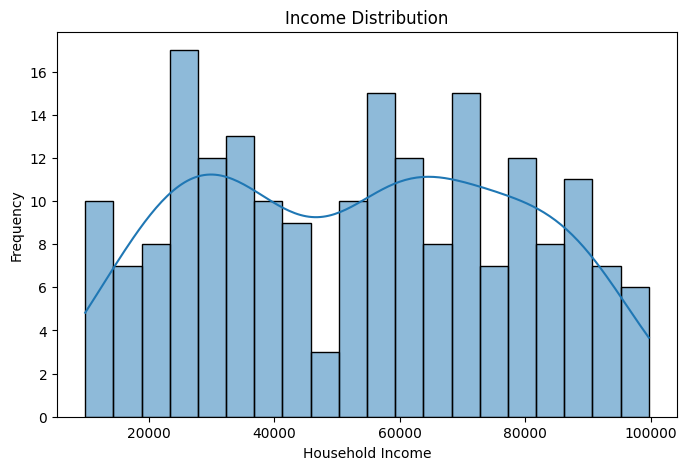

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df["Household_Income"],bins=20 , kde=True)
plt.title("Income Distribution")
plt.xlabel("Household Income")
plt.ylabel("Frequency")
plt.show()

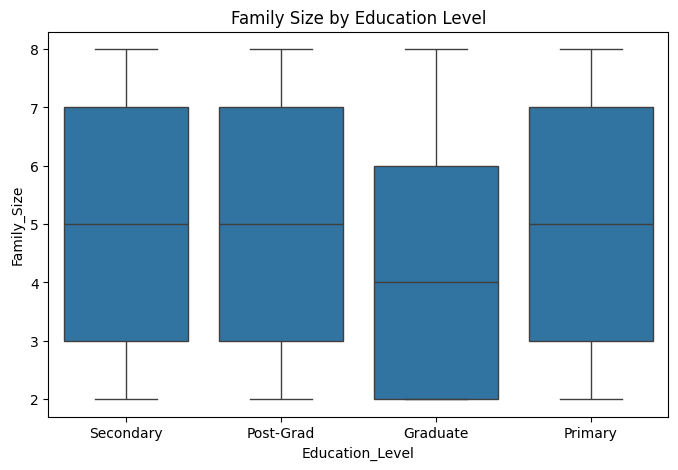

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Education_Level", y="Family_Size", data=df)
plt.title("Family Size by Education Level")
plt.show()

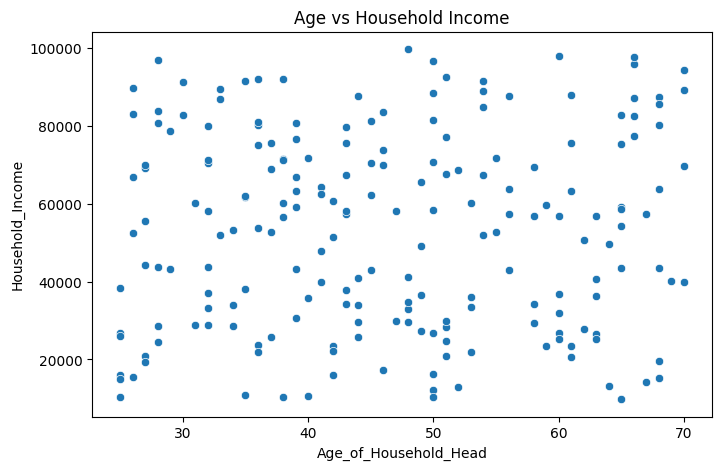

In [28]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Age_of_Household_Head", y="Household_Income", data=df)
plt.title("Age vs Household Income")
plt.show()

In [30]:
print("Average Income by Area:")
print(df.groupby("Urban_Rural")["Household_Income"].mean())

Average Income by Area:
Urban_Rural
Rural    55396.865385
Urban    50769.260417
Name: Household_Income, dtype: float64


In [31]:
print("Average Income by Area:")
print(df.groupby("Urban_Rural")["Household_Income"].median())

Average Income by Area:
Urban_Rural
Rural    57663.0
Urban    50500.0
Name: Household_Income, dtype: float64


In [32]:
print("Average Income by Education Level:")
print(df.groupby("Education_Level")["Household_Income"].mean())

Average Income by Education Level:
Education_Level
Graduate     53853.460000
Post-Grad    45796.533333
Primary      58674.619048
Secondary    54242.412698
Name: Household_Income, dtype: float64


In [33]:
print("Average Income by Education Level:")
print(df.groupby("Education_Level")["Household_Income"].median())

Average Income by Education Level:
Education_Level
Graduate     50965.0
Post-Grad    40599.0
Primary      66912.0
Secondary    56662.0
Name: Household_Income, dtype: float64


In [38]:
print("Average Income by Area & Education Level:")

print(df.groupby(["Urban_Rural","Education_Level"])["Household_Income"].mean())

Average Income by Area & Education Level:
Urban_Rural  Education_Level
Rural        Graduate           57898.956522
             Post-Grad          45950.041667
             Primary            65783.826087
             Secondary          53346.147059
Urban        Graduate           50407.296296
             Post-Grad          45621.095238
             Primary            50068.736842
             Secondary          55293.206897
Name: Household_Income, dtype: float64


In [39]:
print("Average Income by Area & Education Level:")

print(df.groupby(["Urban_Rural","Education_Level"])["Household_Income"].median())

Average Income by Area & Education Level:
Urban_Rural  Education_Level
Rural        Graduate           56897.0
             Post-Grad          40264.5
             Primary            69748.0
             Secondary          54994.5
Urban        Graduate           43444.0
             Post-Grad          43181.0
             Primary            58076.0
             Secondary          57351.0
Name: Household_Income, dtype: float64
